# Aprendizaje Automático — Semana 8 - Aprendizaje No Supervisado
## Instancia de Autoevaluación: Segmentación de Clientes con K-Means
**Tecnicatura Superior en Ciencias de Datos e Inteligencia Artificial**  
Politécnico Malvinas Argentinas

---

## 🎯 Objetivo
En este trabajo voy a aplicar elalgoritmo de aprendizaje no supervisado K-Means sobre un dataset de comportamiento de clientes.

Tengo como objetivo identificar segmentos latentes de clientes a partir de sus comportamientos de compra y uso del sitio, sin etiquetas previas.

La segmentación permitirá detectar perfiles de consumo diferenciados para diseñar estrategias de marketing específicas.

**Dataset:** `dataset_segmentacion_clientes.csv`

---

## 📋 Variables utilizadas
| Variable | Descripción |
|---|---|
| `purchase_freq_month` | Frecuencia de compras por mes |
| `avg_basket_usd` | Ticket promedio por compra (USD) |
| `time_on_site_min` | Tiempo en el sitio (minutos) |
| `discount_sensitivity` | Sensibilidad a descuentos (0 a 1) |
| `returns_rate` | Tasa de devoluciones (0 a 0.8) |

> **Nota:** El dataset contiene además dos columnas de ruido (`noise_gauss`, `noise_uniform`) que serán descartadas por no aportar información de negocio.

## 1. Importación de librerías

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score

import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficos
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 110


## 2. Carga y exploración del dataset

In [19]:
df = pd.read_csv('/content/drive/MyDrive/Aprendizaje Automático/Archivos semana 8/dataset_segmentacion_clientes.csv')
print("Shape:", df.shape)
df.head()


Shape: (700, 7)


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
0,11.152508,181.300834,33.564036,1.000000,0.800000,-1.806578,-2.516905
1,12.053451,178.637272,35.432081,0.784974,0.000000,0.645129,2.115460
2,2.203006,450.185298,7.030757,0.898297,0.000000,-0.047406,-0.724173
3,4.233314,89.006342,10.834453,0.000000,0.800000,0.901700,-2.974026
4,1.716799,449.773982,7.254548,0.000000,0.003279,0.386013,2.424522


In [20]:
df.describe().round(2)

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
count,700.00,700.00,700.00,700.00,700.00,700.00,700.00
mean,5.88,248.17,16.78,0.43,0.34,0.02,-0.01
std,4.47,154.90,12.91,0.43,0.36,1.01,1.68
min,0.10,86.99,3.16,0.00,0.00,-3.57,-2.99
25%,2.28,90.77,6.60,0.00,0.00,-0.65,-1.42
50%,4.13,180.22,9.97,0.30,0.17,0.08,0.01
75%,11.21,449.72,34.34,1.00,0.80,0.73,1.41
max,14.60,452.97,38.35,1.00,0.80,2.86,3.00


In [21]:
print("\n--- INFO ---")
print(df.info())


--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   purchase_freq_month   700 non-null    float64
 1   avg_basket_usd        700 non-null    float64
 2   time_on_site_min      700 non-null    float64
 3   discount_sensitivity  700 non-null    float64
 4   returns_rate          700 non-null    float64
 5   noise_gauss           700 non-null    float64
 6   noise_uniform         700 non-null    float64
dtypes: float64(7)
memory usage: 38.4 KB
None


In [22]:
# Verificar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
purchase_freq_month     0
avg_basket_usd          0
time_on_site_min        0
discount_sensitivity    0
returns_rate            0
noise_gauss             0
noise_uniform           0
dtype: int64


> **Nota:** El dataset contiene 700 registros/clientes y 7 columnas (2 de ellas serán descartadas). No contiene valores nulos.

## 3. Mapa de correlación

Antes de escalar, analizo las relaciones lineales reales entre variables originales.  
- El mapa de correlación se realiza **sobre los datos originales** ya que el coeficiente de Pearson no cambia con transformaciones lineales — el resultado sería idéntico después de aplicar `StandardScaler`.

Realizo el mapa para detectar relaciones fuertes entre variables, o si existe redundancia que pueda sesgar los clusters. Tambien para comprender el comportamiento del dataset.


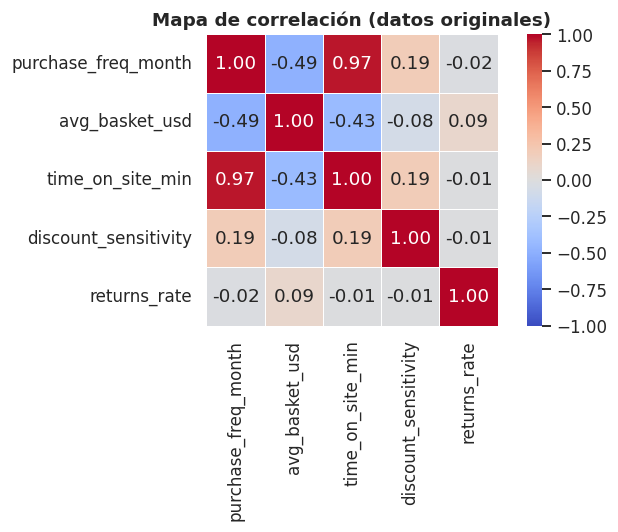

Pares con correlación alta (|r| > 0.5):
  purchase_freq_month ↔ time_on_site_min: 0.97


In [23]:
fig, ax = plt.subplots(figsize=(7, 5))

FEAT_CORR = ['purchase_freq_month', 'avg_basket_usd', 'time_on_site_min', 'discount_sensitivity', 'returns_rate']
corr_matrix = df[FEAT_CORR].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax
)

ax.set_title('Mapa de correlación (datos originales)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('correlacion.png', bbox_inches='tight')
plt.show()

print("Pares con correlación alta (|r| > 0.5):")
for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if row < col:
            val = corr_matrix.loc[row, col]
            if abs(val) > 0.5:
                print(f"  {row} ↔ {col}: {val:.2f}")


> **Nota:** El mapa de correlación me permite ver que:
- Clientes frecuentes vs ticket promedio: (corr. negativa) quines compran mas seguido, pueden gastar menos por compra.
- Sencibilidad al descuento: (corr. negativa) podrían ser que los clientes sencibles al precio realizan compras de menor valor.
- Tiempo en sitio vs clientes frecuentes: (corr. positiva) los clientes que pasan mas tiempo en el sitio podrían comprar con mayor frecuencia.

## 4. Selección de variables y escalado

Descarto `noise_gauss` y `noise_uniform` ya que son ruido sin significado de negocio.

K-Means usa distancias euclidianas, por lo que **es imprescindible escalar** las variables:  
`avg_basket_usd` tiene valores en cientos de dólares, mientras que `discount_sensitivity` va de 0 a 1.  
Sin escalar, el ticket promedio dominaría el cálculo de distancias.


In [24]:
# Variables de interés (se descartan las columnas de ruido)
features = ['purchase_freq_month', 'avg_basket_usd', 'time_on_site_min',
            'discount_sensitivity', 'returns_rate']

X = df[features].copy()

# Escalado estándar (media=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("Primeras filas escaladas:")
X_scaled_df.head()


Primeras filas escaladas:


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate
0,1.181048,-0.432012,1.300224,1.333423,1.298671
1,1.382696,-0.449219,1.444979,0.834706,-0.946196
2,-0.822026,1.305039,-0.755841,1.097540,-0.946196
3,-0.367604,-1.028253,-0.461093,-0.985910,1.298671
4,-0.930849,1.302382,-0.738500,-0.985910,-0.936996


## 5. Distribución de las variables

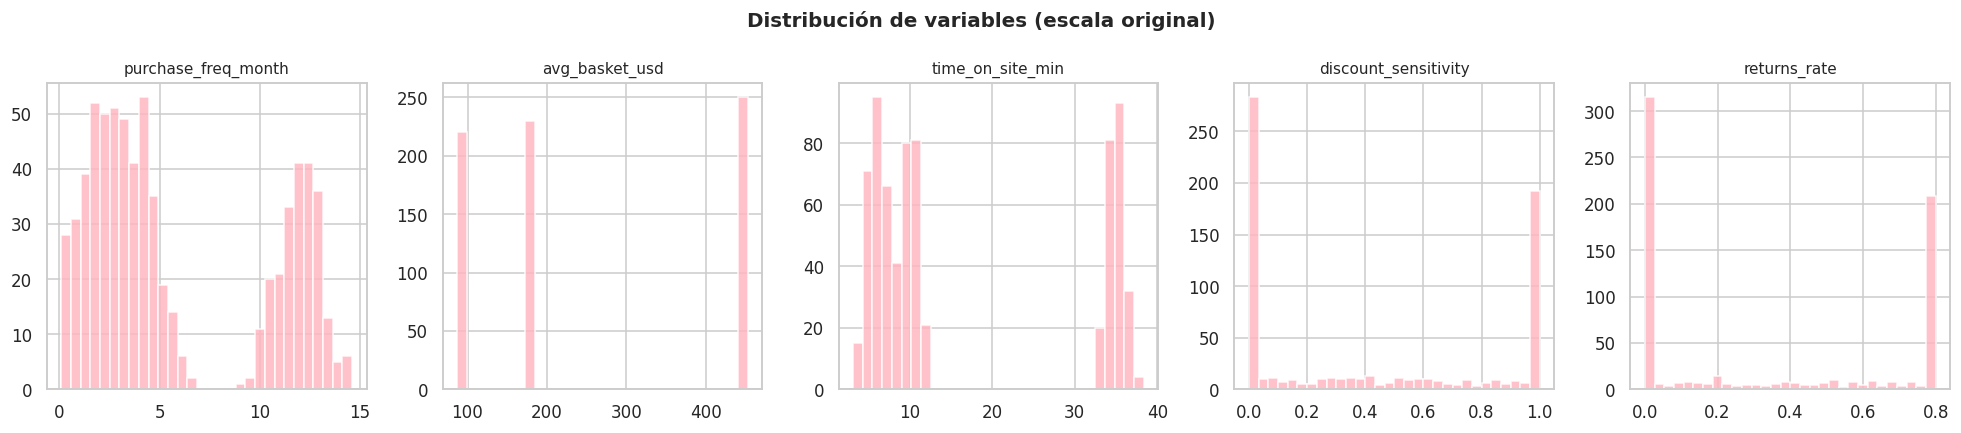

In [25]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, features):
    ax.hist(X[col], bins=30, color='lightpink', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=10)

    ax.set_xlabel('')
fig.suptitle('Distribución de variables (escala original)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dist_variables.png', bbox_inches='tight')
plt.show()


> **Nota:** Estos gráficos de barras, muestran la distribución de las variables:
- `purchase_freq_month`: se observan dos grupos bien definidos, uno con baja frecuencia de compras y otro con alta. Puede evidenciar que existen dos perfiles distintos de clientes.
- `avg_basquet_usd`: se notan 3 grupos diferentes y separados. Podríamos decir que se dividen en compras pequeñas, medias o altas.
- `time_on_site_min`: se observan dos grupos, clientes que navegan poco tiempo y otro grupo de clientes que navegan mucho mas.
- `discount_sensitivity`: acá se notan valores extremos entre los muy sencibles y los pocos sencibles, auqnue tambien hay clientes intermedios.
- `returns_rate`: al igual que en 'sencibilidad', se ven dos grupos extremos, muchos clientes con devoluciones bajas y otro grupo con devoluciones altas.

> A partir de estas distribuciones, se puede ver que algunas variables ya presentan agrupamientos naturales.

## 6. Comparar valores de `k`entre 2 y 6 usando tres métricas distintas
- Método del codo (Inercia). El punto donde la curva "dobla" indica el k óptimo.
- Sihouette Score
- Davies-Bouldin Index




El mejor equilibrio entre inercia, silhouette score y Davies-Bouldin se observa en k=3.


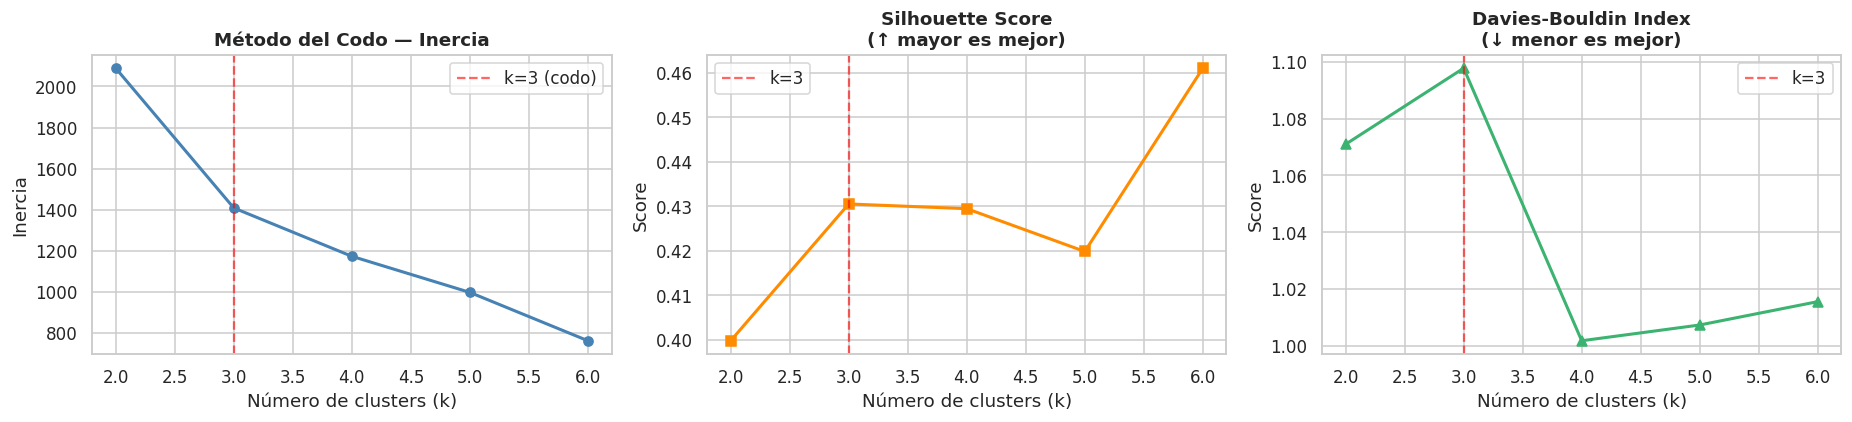

   k |    Inercia |   Silhouette |   Davies-Bouldin
--------------------------------------------------
  2  |     2088.9 |       0.3997 |           1.0710
  3  |     1408.7 |       0.4305 |           1.0978
  4  |     1173.4 |       0.4295 |           1.0017
  5  |      997.7 |       0.4198 |           1.0073
  6  |      762.5 |       0.4610 |           1.0155


In [26]:
inertias = []
silhouettes = []
db_scores = []
K_range = range(2, 7)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))
    db_scores.append(davies_bouldin_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

print("El mejor equilibrio entre inercia, silhouette score y Davies-Bouldin se observa en k=3.")

# Curva del codo
axes[0].plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Método del Codo — Inercia', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.6, label='k=3 (codo)')
axes[0].legend()

# Silhouette Score (mayor = mejor)
axes[1].plot(K_range, silhouettes, marker='s', color='darkorange', linewidth=2)
axes[1].set_title('Silhouette Score\n(↑ mayor es mejor)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Score')
axes[1].axvline(x=3, color='red', linestyle='--', alpha=0.6, label='k=3')
axes[1].legend()

# Davies-Bouldin Index (menor = mejor)
axes[2].plot(K_range, db_scores, marker='^', color='mediumseagreen', linewidth=2)
axes[2].set_title('Davies-Bouldin Index\n(↓ menor es mejor)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Número de clusters (k)')
axes[2].set_ylabel('Score')
axes[2].axvline(x=3, color='red', linestyle='--', alpha=0.6, label='k=3')
axes[2].legend()

plt.tight_layout()
plt.savefig('elbow_silhouette_db.png', bbox_inches='tight')
plt.show()

print(f"{'k':>4} | {'Inercia':>10} | {'Silhouette':>12} | {'Davies-Bouldin':>16}")
print("-" * 50)
for k, iner, sil, db in zip(K_range, inertias, silhouettes, db_scores):
    print(f"  {k}  | {iner:>10.1f} | {sil:>12.4f} | {db:>16.4f}")


> **Nota**: Para elegir el número óptimo de clusters evalué distintas métricas. - El método del codo muestra una reducción de la inercia hasta k=3 donde comienza a normalizarse.
- El Silhouette Score también mejora a partir de k=3 repecto de k=2, y aunque aparecen valores mayores de k, elijo k=3 para equilibrar las distintas métricas.
- En Davies-Bouldin, mide que tan compactos estan los clusters, cuanto menor sea el resultado, mejor. En este caso el mejor resultado fue en k=4, pero la diferencia con k=3 es pequeña.

## 7. Entrenamiento del modelo final (k=3)

Basándonos en el método del codo, Silhouette Score y Davies-Bouldin, **k=3** es el valor más razonable.


In [27]:
K_OPTIMO = 3

kmeans_final = KMeans(n_clusters=K_OPTIMO, init='k-means++', n_init=10,
                  max_iter=300, random_state=42)
kmeans_final.fit(X_scaled)

df['cluster'] = kmeans_final.labels_

print(f"Inercia final (k={K_OPTIMO}): {kmeans_final.inertia_:.2f}")
print(f"Silhouette Score:      {silhouette_score(X_scaled, kmeans_final.labels_):.4f}  (↑ mayor es mejor, máx=1)")
print(f"Davies-Bouldin Index:  {davies_bouldin_score(X_scaled, kmeans_final.labels_):.4f}  (↓ menor es mejor, mín=0)")
print()
print("Distribución de clientes por cluster:")
print(df['cluster'].value_counts().sort_index())


Inercia final (k=3): 1408.70
Silhouette Score:      0.4305  (↑ mayor es mejor, máx=1)
Davies-Bouldin Index:  1.0978  (↓ menor es mejor, mín=0)

Distribución de clientes por cluster:
cluster
0    230
1    250
2    220
Name: count, dtype: int64


> **Nota**: el entrenamiento final segmentó a los 700 clientes en 3 clusters. Las métricas muestran una buena calidad de agrupamiento, con clusters bien separados. La distribución balanceada, mustra que el modelo logró identificar perfiles claros y útiles para el análisis.

## 8. Análisis de centroides — Perfiles de cada segmento

In [28]:
# Centroides en escala original (más interpretable)
centroids_original = scaler.inverse_transform(kmeans_final.cluster_centers_)
centroids_df = pd.DataFrame(centroids_original, columns=features)
centroids_df.index.name = 'cluster'
centroids_df.round(3)


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate
cluster,,,,,
0,11.961,179.999,35.022,0.542,0.332
1,1.847,450.124,5.974,0.358,0.375
2,4.092,89.958,10.004,0.379,0.299


In [29]:
# Media de cada variable por cluster (sobre datos originales)
perfil = df.groupby('cluster')[features].mean().round(3)
print("=== Perfil de cada cluster (valores medios) ===")
perfil


=== Perfil de cada cluster (valores medios) ===


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate
cluster,,,,,
0,11.961,179.999,35.022,0.542,0.332
1,1.847,450.124,5.974,0.358,0.375
2,4.092,89.958,10.004,0.379,0.299


>**Nota:** Los centroides representan al 'cliente promedio' de cada grupo.

### Heatmap de centroides escalados

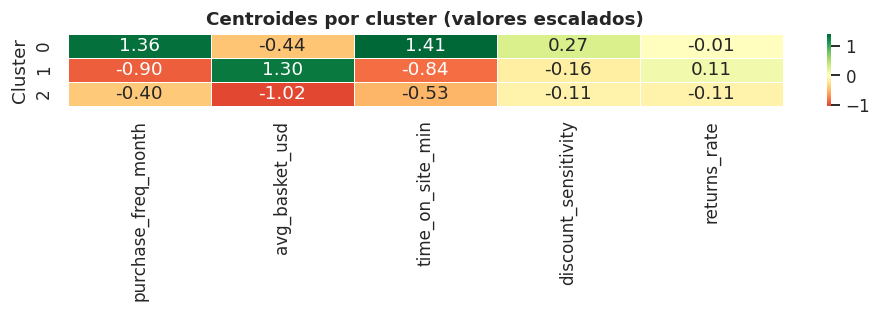

In [30]:
fig, ax = plt.subplots(figsize=(9, 3))
sns.heatmap(
    pd.DataFrame(kmeans_final.cluster_centers_, columns=features),
    annot=True, fmt='.2f', cmap='RdYlGn', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('Centroides por cluster (valores escalados)', fontsize=12, fontweight='bold')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()


> **Nota:**: Acá puedo ver y comparar de forma rápida, qué variables estan por encima, cerca o debajo del promedio en cada grupo. Como los datos estan escalados, 0 (cero) es el promedio general. Entonces:

- Positivo -> por encima del promedio
- Negativo -> por dejado del promedio
- Mas lejos de 0 -> mas fuerte la diferencia



## 9. Distribución de variables por cluster

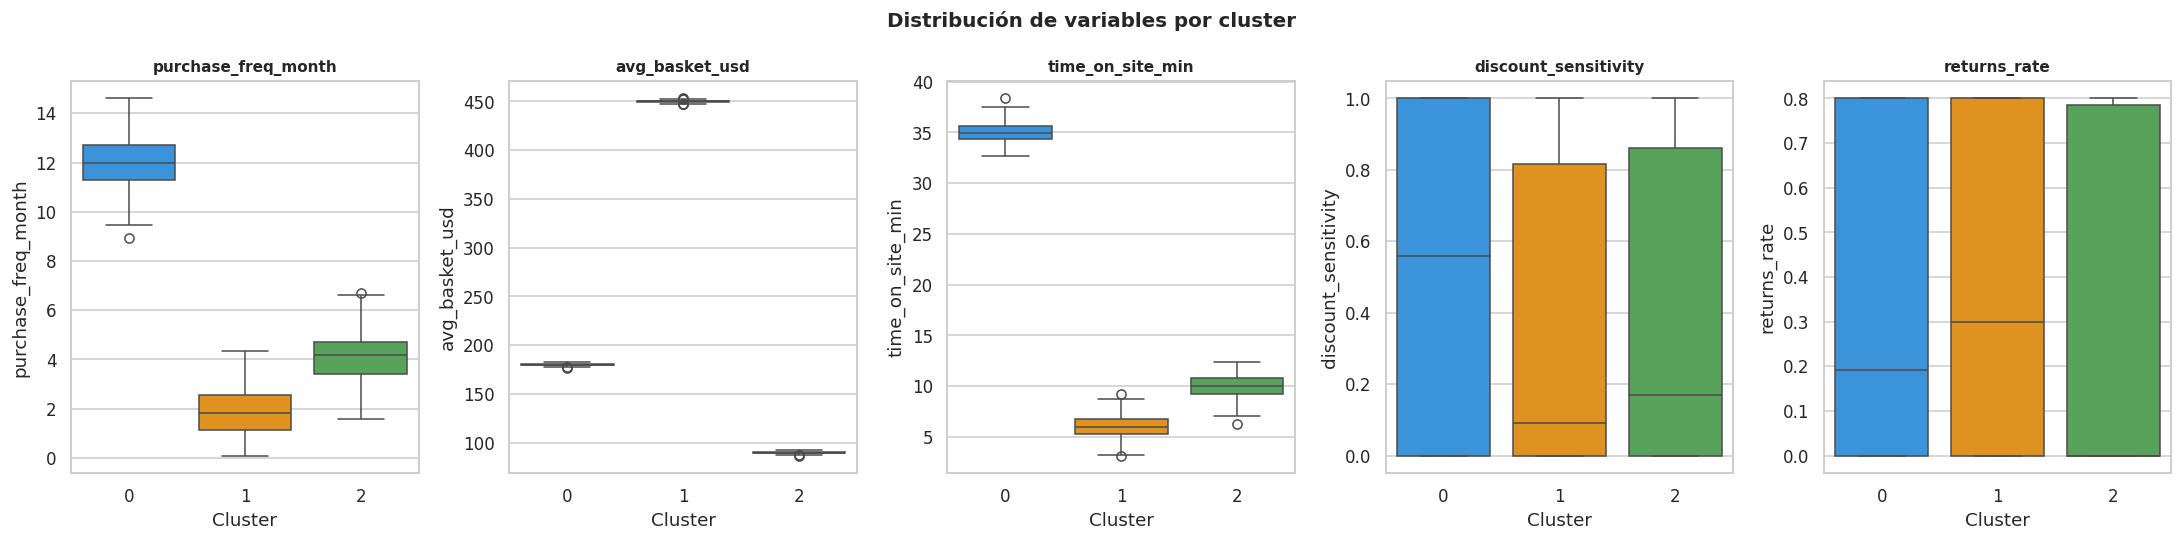

In [31]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
palette = {'0': '#2196F3', '1': '#FF9800', '2': '#4CAF50'}

for ax, col in zip(axes, features):
    df_plot = df.copy(); df_plot['cluster'] = df_plot['cluster'].astype(str)
    sns.boxplot(data=df_plot, x='cluster', y=col, palette=palette, ax=ax)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Cluster')

fig.suptitle('Distribución de variables por cluster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_clusters.png', bbox_inches='tight')
plt.show()


## 10. Visualización de clusters — Scatter plots clave

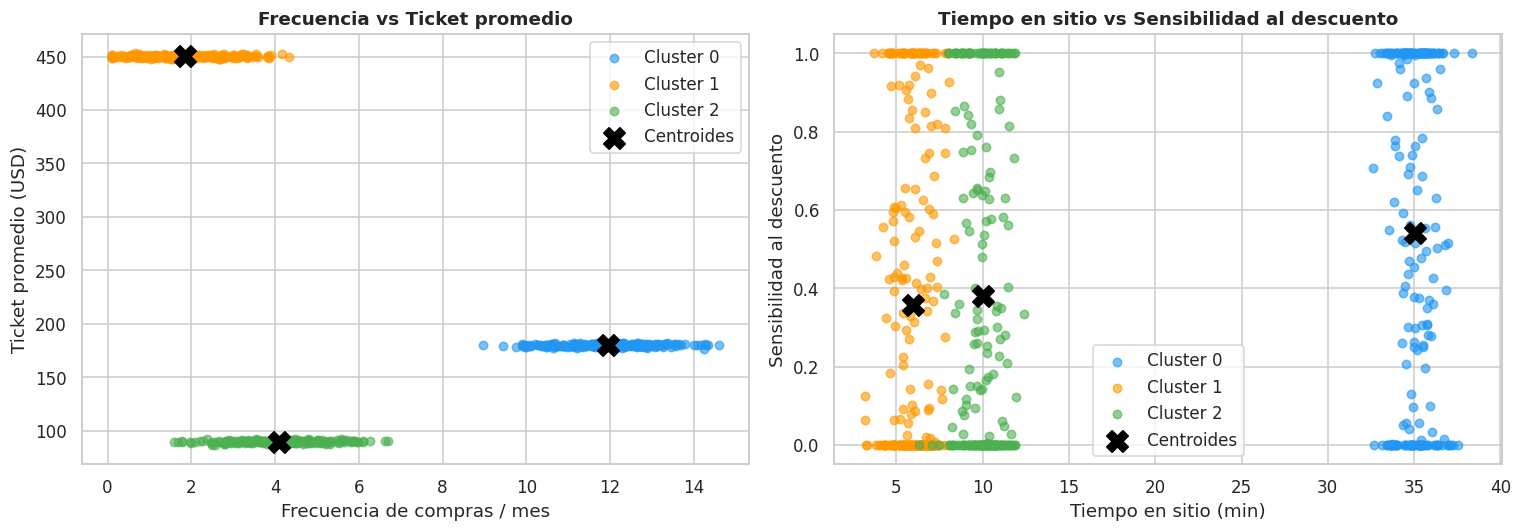

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = {0: '#2196F3', 1: '#FF9800', 2: '#4CAF50'}

# Frecuencia vs ticket
for cluster_id, color in palette.items():
    mask = df['cluster'] == cluster_id
    axes[0].scatter(
        df.loc[mask, 'purchase_freq_month'],
        df.loc[mask, 'avg_basket_usd'],
        c=color, label=f'Cluster {cluster_id}', alpha=0.6, s=30
    )
# Centroides
cx = scaler.inverse_transform(kmeans_final.cluster_centers_)
axes[0].scatter(cx[:, 0], cx[:, 1], c='black', marker='X', s=200, zorder=5, label='Centroides')
axes[0].set_xlabel('Frecuencia de compras / mes')
axes[0].set_ylabel('Ticket promedio (USD)')
axes[0].set_title('Frecuencia vs Ticket promedio', fontweight='bold')
axes[0].legend()

# Tiempo en sitio vs sensibilidad al descuento
for cluster_id, color in palette.items():
    mask = df['cluster'] == cluster_id
    axes[1].scatter(
        df.loc[mask, 'time_on_site_min'],
        df.loc[mask, 'discount_sensitivity'],
        c=color, label=f'Cluster {cluster_id}', alpha=0.6, s=30
    )
axes[1].scatter(cx[:, 2], cx[:, 3], c='black', marker='X', s=200, zorder=5, label='Centroides')
axes[1].set_xlabel('Tiempo en sitio (min)')
axes[1].set_ylabel('Sensibilidad al descuento')
axes[1].set_title('Tiempo en sitio vs Sensibilidad al descuento', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('scatter_clusters.png', bbox_inches='tight')
plt.show()


## 11. Diagrama de Silhouette — Calidad de la segmentación

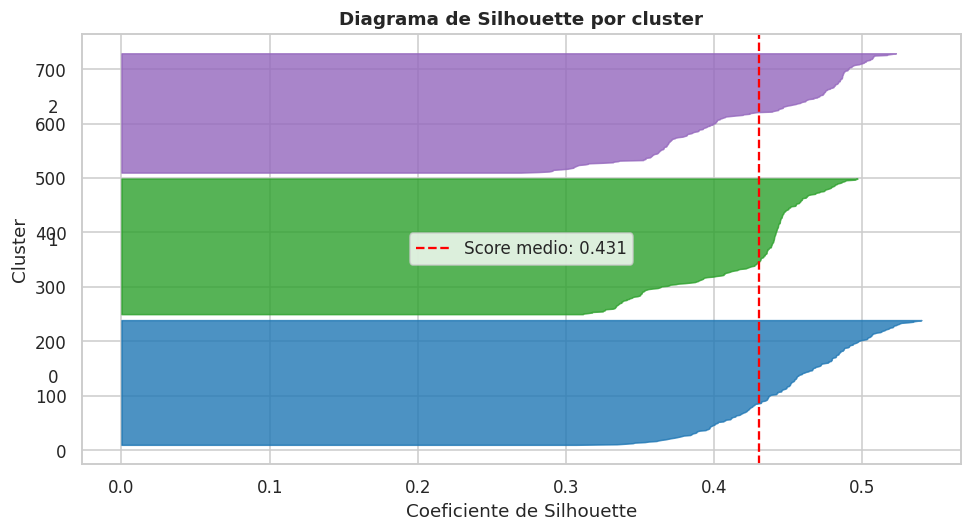

In [33]:
fig, ax = plt.subplots(figsize=(9, 5))

sil_vals = silhouette_samples(X_scaled, kmeans_final.labels_)
y_lower = 10
colors = cm.tab10(np.linspace(0, 0.4, K_OPTIMO))

for i in range(K_OPTIMO):
    cluster_sil = np.sort(sil_vals[kmeans_final.labels_ == i])
    size = cluster_sil.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=11)
    y_lower = y_upper + 10

avg_sil = silhouette_score(X_scaled, kmeans_final.labels_)
ax.axvline(x=avg_sil, color='red', linestyle='--', label=f'Score medio: {avg_sil:.3f}')
ax.set_title('Diagrama de Silhouette por cluster', fontsize=12, fontweight='bold')
ax.set_xlabel('Coeficiente de Silhouette')
ax.set_ylabel('Cluster')
ax.legend()
plt.tight_layout()
plt.savefig('silhouette_plot.png', bbox_inches='tight')
plt.show()


## 12. Predicción de nuevos clientes

Una vez entrenado el modelo, podemos usarlo para **predecir a qué segmento pertenece un cliente nuevo** sin necesidad de reentrenar.

El único requisito es aplicar el **mismo escalado** (`scaler`) que usamos durante el entrenamiento.


In [34]:
# Definimos tres clientes nuevos con perfiles distintos
nuevos_clientes = pd.DataFrame({
    'purchase_freq_month':  [12.0,  1.5,  5.0],
    'avg_basket_usd':       [95.0, 445.0, 185.0],
    'time_on_site_min':     [22.0,  10.0,  40.0],
    'discount_sensitivity': [0.85,  0.10,  0.50],
    'returns_rate':         [0.20,  0.05,  0.35]
}, index=['Cliente A', 'Cliente B', 'Cliente C'])

print("Datos de los nuevos clientes:")
print(nuevos_clientes)
print()

# Escalar con el MISMO scaler entrenado
nuevos_scaled = scaler.transform(nuevos_clientes)

# Predecir cluster
predicciones = kmeans_final.predict(nuevos_scaled)

nuevos_clientes['cluster_predicho'] = predicciones

# Mapa de perfil para interpretar
perfil_nombre = {0: 'Frecuente/precio-sensible', 1: 'Esporádico/alto valor', 2: 'Explorador/mixto'}
nuevos_clientes['perfil'] = nuevos_clientes['cluster_predicho'].map(perfil_nombre)

print("Resultado de la predicción:")
print(nuevos_clientes[['cluster_predicho', 'perfil']])


Datos de los nuevos clientes:
           purchase_freq_month  avg_basket_usd  time_on_site_min  \
Cliente A                 12.0            95.0              22.0   
Cliente B                  1.5           445.0              10.0   
Cliente C                  5.0           185.0              40.0   

           discount_sensitivity  returns_rate  
Cliente A                  0.85          0.20  
Cliente B                  0.10          0.05  
Cliente C                  0.50          0.35  

Resultado de la predicción:
           cluster_predicho                     perfil
Cliente A                 0  Frecuente/precio-sensible
Cliente B                 1      Esporádico/alto valor
Cliente C                 0  Frecuente/precio-sensible


## 13. Interpretación de los segmentos

A partir del análisis de centroides y distribuciones, se identifican **3 perfiles de clientes**:

---

### 🔵 Cluster 0 — *Compradores frecuentes y sensibles al precio*
- **Alta** frecuencia de compras por mes
- **Ticket bajo** (ronda los ~90 USD)
- **Alta** sensibilidad a descuentos
- Tiempo en sitio moderado
- Tasa de devoluciones moderada

**Posible estrategia:** Foco en promociones, descuentos y programas de fidelización.  
Son clientes que compran mucho pero en montos pequeños; incentivos frecuentes pueden aumentar su ticket promedio.

---

### 🟠 Cluster 1 — *Compradores de alto valor*
- **Baja** frecuencia de compras por mes
- **Ticket alto** (~450 USD)
- **Baja** sensibilidad a descuentos
- Tiempo en sitio más corto (saben lo que buscan)
- Tasa de devoluciones baja

**Posible estrategia:** Upselling (mejorar el producto elegido) y cross-selling (añadir productos complementarios) premium.  
Son clientes valiosos que no necesitan descuentos; apuntar a experiencia VIP y productos de alta gama.

---

### 🟢 Cluster 2 — *Compradores con comportamiento mixto*
- Frecuencia de compras **media**
- Ticket **medio** (~180 USD)
- Sensibilidad a descuentos **media**
- **Mayor** tiempo en sitio
- **Mayor** tasa de devoluciones

**Posible estrategia:** Mejorar la experiencia de producto.

Su alto tiempo en sitio y mayor tasa de devoluciones sugiere que exploran pero no siempre quedan satisfechos.


---
#Importante
###¿Por qué se utiliza K-Means?
K-Means es un algoritmo de clustering no supervisado que agrupa observaciones similares minimizando la distancia entre los datos y el centroide de cada grupo.

Se puede utilizar este algoritmo porque: no existen etiquetas previas, tiene como objetivo descubrir patrones ocultos, funciona con variables numéricas continuas y permite interpretar los centroides de cada segmento.



---

## 14. Conclusiones

- El **método del codo** junto al **Silhouette Score** y **Davies-Bouldin** confirmaron que **k=3** es el número óptimo de clusters para este dataset.
- El algoritmo **K-Means** logró separar tres perfiles de clientes claramente diferenciados en cuanto a frecuencia de compra, ticket promedio y sensibilidad al precio.
- El **escalado previo** con `StandardScaler` fue esencial para evitar que variables como `avg_basket_usd` (en cientos de dólares) dominaran el modelo.
- Las columnas de ruido (`noise_gauss`, `noise_uniform`) fueron descartadas.
- Los tres segmentos obtenidos permiten diseñar **estrategias de marketing diferenciadas**: promociones para el Cluster 0, upselling premium para el Cluster 1, y mejora de experiencia de producto para el Cluster 2.
